# Stacked tSZ profiles: empirical aperture-normalised estimator

We measure a **fully empirical** stacked Compton-$y$ profile straight from the pixelized map, **without** assuming a pressure-profile model and **without** using the central value $y_0$ (which is not directly measurable from a pixelized map).

For each cluster $a$ we work in scaled angular radius $x \equiv \theta/\theta_{500,a}$ and measure:

- the **annular mean** in each scaled bin $i$ (equal pixel weights $w_p=1$ on the equal-area HEALPix map),
  $$\bar y_{i,a} = \frac{\sum_{p\in i(a)} w_p\,y_p}{\sum_{p\in i(a)} w_p};$$
- the **aperture-integrated** Compton-$y$ inside $R_{500}$, converted to an aperture **mean**,
  $$Y_{500,a} = \sum_{\theta_p<\theta_{500,a}} y_p\,\Omega_{\rm pix},\qquad
    y_{{\rm norm},a} = \frac{Y_{500,a}}{\pi\theta_{500,a}^2}.$$

The per-cluster dimensionless profile and the stack (equal weights $W_{i,a}=1$) are
$$g_{i,a}=\frac{\bar y_{i,a}}{y_{{\rm norm},a}},\qquad
  \hat f_i=\frac{\sum_a W_{i,a}\,g_{i,a}}{\sum_a W_{i,a}}.$$

We plot $\hat f_i$ vs the area-weighted bin centre $x_i$. The Arnaud A10 projected GNFW reference is normalised the **same** way (divided by its own aperture mean inside $x<1$) and annulus-averaged in the same $x$ bins, so the comparison is consistent. The stacking is defined in this notebook; we do not use `flamingo.profiles.stacking`.

We produce **two plots**: the massive stack and the small-mass stack.

In [14]:
import os

# Limit JAX GPU memory allocation to 10% for prefilling
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.10'

import numpy as np
import numpy as np
import pandas as pd
import healpy as hp
import matplotlib.pyplot as plt

from flamingo import paths
from flamingo.maps import read_map
from flamingo.catalogue import load_catalogue
from flamingo.geometry import query_disc_separation, ARCMIN_PER_RAD
from flamingo.profiles import projected_shape, gnfw, A10_PARAMS

path_highres = '/rds/rds-lxu/tsz_project/flamingo_highres_maps/y_unlensed_L2p8_m9_lc0_nside16384.fits'

# ymap = read_map(paths.HYDRO_MAP)
ymap = read_map(path_highres)
df = load_catalogue(paths.HYDRO_CATALOGUE)
NSIDE = hp.npix2nside(ymap.size)
OMEGA_PIX = hp.nside2pixarea(NSIDE)   # solid angle per pixel [sr]
print('clusters', len(df), '| NSIDE', NSIDE)

clusters 1555542 | NSIDE 16384


In [15]:
# Fixed redshift window so the two stacks differ only in mass.
N_STACK = 1000
window = df[(df['z'] > 0.) & (df['z'] < 3.0)]
massive = window.nlargest(N_STACK, 'M_500c_Msun')
# Bootstrap N_STACK clusters from those not in 'massive'
exclude_indices = massive.index
non_massive = window.drop(exclude_indices)
small = non_massive.sample(n=N_STACK, replace=True, random_state=43)

for name, s in [('massive', massive), ('small', small)]:
    print(f"{name:8s}  N={len(s)}  "
          f"M500=[{s['M_500c_Msun'].min():.2e}, {s['M_500c_Msun'].max():.2e}]  "
          f"median theta500={s['theta500_arcmin'].median():.2f} arcmin")

massive   N=1000  M500=[7.12e+14, 2.07e+15]  median theta500=3.26 arcmin
small     N=1000  M500=[5.01e+13, 6.44e+14]  median theta500=0.95 arcmin


In [16]:
# Scaled-radius bins x = theta / theta_500 (log-spaced), with area-weighted centres.
x_edges = np.logspace(np.log10(0.01), np.log10(5.0), 101)   # 100 bins, x from 0.01 R500
x_lo, x_hi = x_edges[:-1], x_edges[1:]
x_mid = (2.0 / 3.0) * (x_hi**3 - x_lo**3) / (x_hi**2 - x_lo**2)   # <x> in annulus


def empirical_profile(theta_c, phi_c, theta500_arcmin, x_edges):
    """Empirical per-cluster profile from the y-map. No model, no central y_0.

    Returns
    -------
    ybar : ndarray
        Annular mean Compton-y per scaled-radius bin (equal weights w_p = 1),
        ybar_i = sum_{p in i} y_p / N_i; nan for empty bins.
    y_norm : float
        Aperture-mean Compton-y inside theta < theta500,
        y_norm = Y500 / (pi theta500^2) with Y500 = sum_{theta_p<theta500} y_p Omega_pix.
    """
    theta500_rad = theta500_arcmin / ARCMIN_PER_RAD
    r_out_rad = x_edges[-1] * theta500_rad
    pix, sep_rad = query_disc_separation(NSIDE, theta_c, phi_c, r_out_rad)
    y_p = ymap[pix]
    x = sep_rad / theta500_rad

    ybar = np.full(len(x_edges) - 1, np.nan)
    idx = np.digitize(x, x_edges) - 1
    for b in range(ybar.size):
        sel = idx == b
        if sel.any():
            ybar[b] = y_p[sel].mean()

    inside = x < 1.0
    Y500 = y_p[inside].sum() * OMEGA_PIX
    y_norm = Y500 / (np.pi * theta500_rad**2)
    return ybar, y_norm


def stack_empirical(sample, x_edges):
    """Stack g_{i,a} = ybar_{i,a} / y_norm,a over clusters (equal weights W=1)."""
    g_rows = []
    for _, row in sample.iterrows():
        ybar, y_norm = empirical_profile(
            float(row['theta_rot_rad']), float(row['phi_rot_rad']),
            float(row['theta500_arcmin']), x_edges)
        if np.isfinite(y_norm) and y_norm > 0:
            g_rows.append(ybar / y_norm)
    G = np.vstack(g_rows)
    n = np.sum(np.isfinite(G), axis=0)
    fhat = np.nanmean(G, axis=0)
    sem = np.nanstd(G, axis=0) / np.sqrt(np.maximum(n, 1))
    p16, p84 = np.nanpercentile(G, [16, 84], axis=0)
    return dict(fhat=fhat, sem=sem, p16=p16, p84=p84, n=G.shape[0])


def aperture_mean_inside_one(shape_func):
    """Area-weighted aperture mean of a projected model inside x < 1."""
    xa = np.linspace(0.0, 1.0, 800)
    fa = np.asarray(shape_func(xa))
    return 2.0 * np.trapezoid(fa * xa, xa)   # int f 2 pi x dx / pi


def aperture_normalised_model(x_grid, shape_func):
    """Continuous aperture-normalised model, useful for visual shape checks."""
    return np.asarray(shape_func(x_grid)) / aperture_mean_inside_one(shape_func)


def binned_aperture_normalised_model(x_edges, shape_func, n_quad=200):
    """Model averaged over the same annuli as the stacked data.

    Data points are annular means, so the exact model comparison in bin i is
    2 int_lo^hi f_norm(x) x dx / (hi^2 - lo^2).
    """
    aperture_mean = aperture_mean_inside_one(shape_func)
    out = []
    for lo, hi in zip(x_edges[:-1], x_edges[1:]):
        xb = np.linspace(lo, hi, n_quad)
        fb = np.asarray(shape_func(xb)) / aperture_mean
        out.append(2.0 * np.trapezoid(fb * xb, xb) / (hi**2 - lo**2))
    return np.asarray(out)


m = stack_empirical(massive, x_edges)
s = stack_empirical(small, x_edges)
print(f'stacked {m["n"]} massive, {s["n"]} small')

xx = np.logspace(np.log10(0.05), np.log10(4.0), 200)
arnaud = binned_aperture_normalised_model(x_edges, projected_shape)


stacked 1000 massive, 1000 small


## Plot 1: massive-cluster stack

Stacked empirical profile $\hat f_i = \langle \bar y_i / (Y_{500}/\pi\theta_{500}^2)\rangle$ for the most massive haloes.

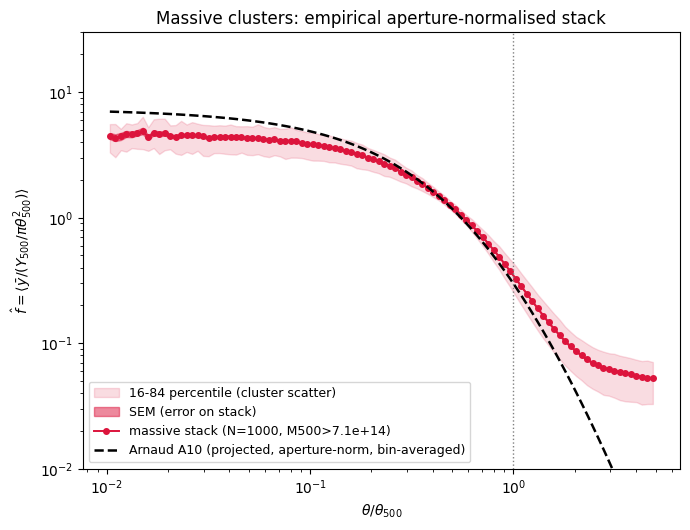

In [17]:
fig, ax = plt.subplots(figsize=(7.0, 5.4))
ax.fill_between(x_mid, m['p16'], m['p84'], color='crimson', alpha=0.15,
                label='16-84 percentile (cluster scatter)')
ax.fill_between(x_mid, m['fhat'] - m['sem'], m['fhat'] + m['sem'],
                color='crimson', alpha=0.5, label='SEM (error on stack)')
ax.plot(x_mid, m['fhat'], 'o-', ms=4, lw=1.4, color='crimson',
        label=f'massive stack (N={m["n"]}, M500>{massive["M_500c_Msun"].min():.1e})')
ax.plot(x_mid, arnaud, 'k--', lw=1.8, label='Arnaud A10 (projected, aperture-norm, bin-averaged)')
ax.axvline(1.0, color='grey', ls=':', lw=1)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$\theta / \theta_{500}$')
ax.set_ylabel(r'$\hat f = \langle \bar y / (Y_{500}/\pi\theta_{500}^2) \rangle$')
ax.set_ylim(1e-2, 3e1)
ax.set_title('Massive clusters: empirical aperture-normalised stack')
ax.legend(fontsize=9)
fig.tight_layout(); plt.show()

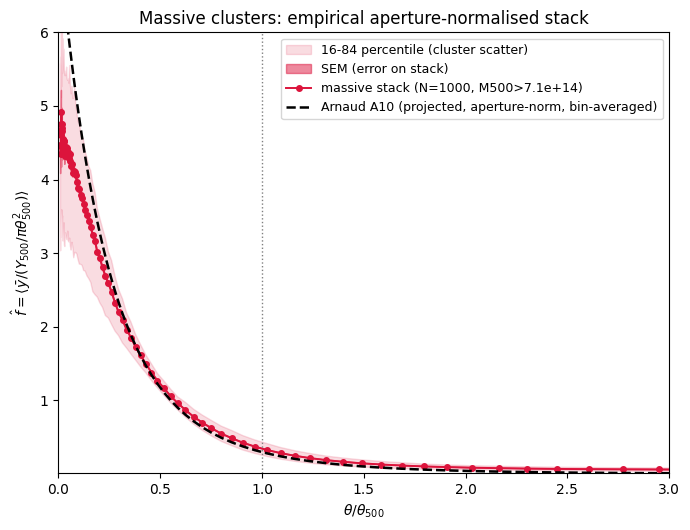

In [18]:
fig, ax = plt.subplots(figsize=(7.0, 5.4))
ax.fill_between(x_mid, m['p16'], m['p84'], color='crimson', alpha=0.15,
                label='16-84 percentile (cluster scatter)')
ax.fill_between(x_mid, m['fhat'] - m['sem'], m['fhat'] + m['sem'],
                color='crimson', alpha=0.5, label='SEM (error on stack)')
ax.plot(x_mid, m['fhat'], 'o-', ms=4, lw=1.4, color='crimson',
        label=f'massive stack (N={m["n"]}, M500>{massive["M_500c_Msun"].min():.1e})')
ax.plot(x_mid, arnaud, 'k--', lw=1.8, label='Arnaud A10 (projected, aperture-norm, bin-averaged)')
ax.axvline(1.0, color='grey', ls=':', lw=1)
ax.set_xscale('linear'); ax.set_yscale('linear')
ax.set_xlabel(r'$\theta / \theta_{500}$')
ax.set_ylabel(r'$\hat f = \langle \bar y / (Y_{500}/\pi\theta_{500}^2) \rangle$')
ax.set_ylim(1e-2, 6)
ax.set_xlim(0, 3)
ax.set_title('Massive clusters: empirical aperture-normalised stack')
ax.legend(fontsize=9)
fig.tight_layout(); plt.show()

## Plot 2: small-mass-cluster stack

Same empirical estimator for the least massive haloes. These have smaller $\theta_{500}$ (near the pixel scale), so the innermost bins are often empty per cluster; the aperture normalisation $y_{\rm norm}=Y_{500}/\pi\theta_{500}^2$ is still well defined and stacking beats down the noise.

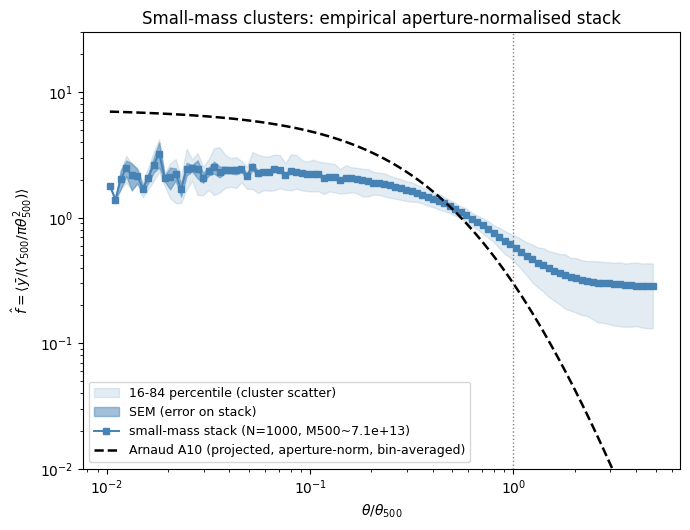

In [19]:
fig, ax = plt.subplots(figsize=(7.0, 5.4))
ax.fill_between(x_mid, s['p16'], s['p84'], color='steelblue', alpha=0.15,
                label='16-84 percentile (cluster scatter)')
ax.fill_between(x_mid, s['fhat'] - s['sem'], s['fhat'] + s['sem'],
                color='steelblue', alpha=0.5, label='SEM (error on stack)')
ax.plot(x_mid, s['fhat'], 's-', ms=4, lw=1.4, color='steelblue',
        label=f'small-mass stack (N={s["n"]}, M500~{small["M_500c_Msun"].median():.1e})')
ax.plot(x_mid, arnaud, 'k--', lw=1.8, label='Arnaud A10 (projected, aperture-norm, bin-averaged)')
ax.axvline(1.0, color='grey', ls=':', lw=1)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$\theta / \theta_{500}$')
ax.set_ylabel(r'$\hat f = \langle \bar y / (Y_{500}/\pi\theta_{500}^2) \rangle$')
ax.set_ylim(1e-2, 3e1)
ax.set_title('Small-mass clusters: empirical aperture-normalised stack')
ax.legend(fontsize=9)
fig.tight_layout(); plt.show()

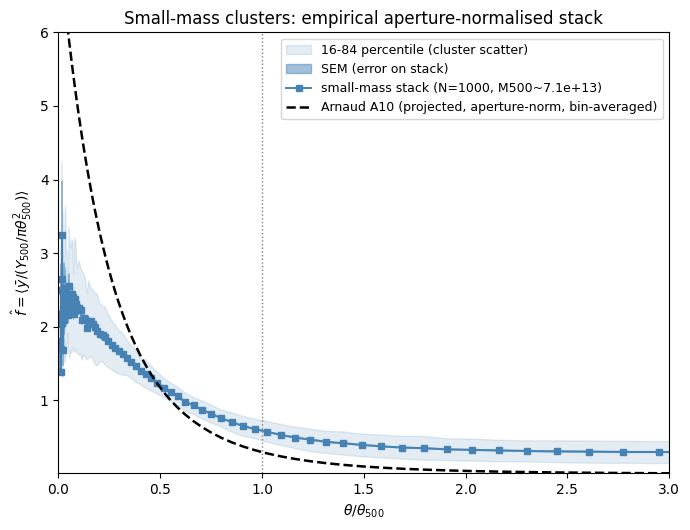

In [20]:
fig, ax = plt.subplots(figsize=(7.0, 5.4))
ax.fill_between(x_mid, s['p16'], s['p84'], color='steelblue', alpha=0.15,
                label='16-84 percentile (cluster scatter)')
ax.fill_between(x_mid, s['fhat'] - s['sem'], s['fhat'] + s['sem'],
                color='steelblue', alpha=0.5, label='SEM (error on stack)')
ax.plot(x_mid, s['fhat'], 's-', ms=4, lw=1.4, color='steelblue',
        label=f'small-mass stack (N={s["n"]}, M500~{small["M_500c_Msun"].median():.1e})')
ax.plot(x_mid, arnaud, 'k--', lw=1.8, label='Arnaud A10 (projected, aperture-norm, bin-averaged)')
ax.axvline(1.0, color='grey', ls=':', lw=1)
ax.set_xscale('linear'); ax.set_yscale('linear')
ax.set_xlabel(r'$\theta / \theta_{500}$')
ax.set_ylabel(r'$\hat f = \langle \bar y / (Y_{500}/\pi\theta_{500}^2) \rangle$')
ax.set_ylim(1e-2, 6)
ax.set_xlim(0, 3)
ax.set_title('Small-mass clusters: empirical aperture-normalised stack')
ax.legend(fontsize=9)
fig.tight_layout(); plt.show()

## GNFW parameter exploration

The Arnaud reference is fully tunable. `projected_shape(x, p_func=...)` accepts any pressure shape, and `gnfw` exposes the five GNFW parameters: central slope $\gamma$, transition width $\alpha$, outer slope $\beta$, concentration $c_{500}$, and amplitude $P_0$. Each variation is run through `aperture_normalised_model` (divided by its own aperture mean inside $x<1$), so it is on the same footing as the empirical stack $\hat f$. The overall amplitude $P_0$ cancels under this normalisation; only $\gamma,\alpha,\beta,c_{500}$ change the curve.

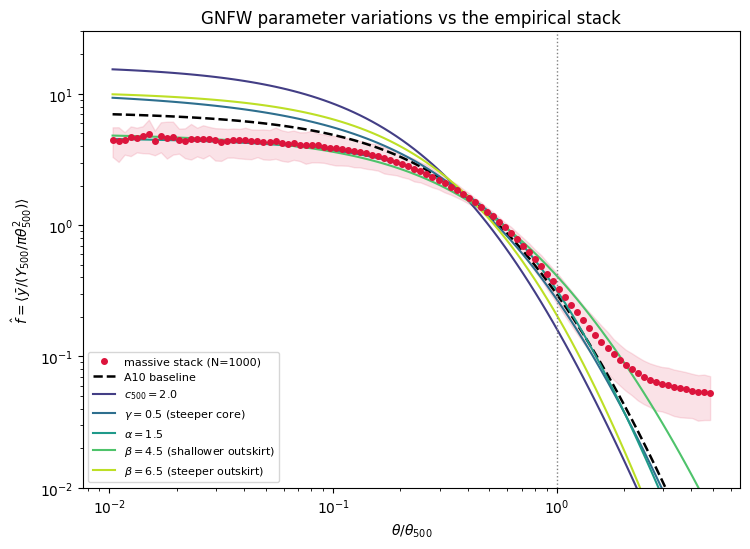

Arnaud A10 defaults: {'P0': 8.403, 'c500': 1.177, 'gamma': 0.3081, 'alpha': 1.051, 'beta': 5.4905}


In [21]:
from functools import partial


def gnfw_projected_norm(x_edges, **params):
    """Projected GNFW shape with custom parameters, annulus-averaged and
    aperture-normalised the same way as the stacked data."""
    shape = lambda b: projected_shape(b, p_func=partial(gnfw, **params))
    return binned_aperture_normalised_model(x_edges, shape)


# Vary one GNFW parameter at a time around the Arnaud A10 baseline.
variations = [
    ("A10 baseline", {}),
    (r"$c_{500}=2.0$", dict(c500=2.0)),
    (r"$\gamma=0.5$ (steeper core)", dict(gamma=0.5)),
    (r"$\alpha=1.5$", dict(alpha=1.5)),
    (r"$\beta=4.5$ (shallower outskirt)", dict(beta=4.5)),
    (r"$\beta=6.5$ (steeper outskirt)", dict(beta=6.5)),
]

fig, ax = plt.subplots(figsize=(7.6, 5.6))
ax.fill_between(x_mid, m["p16"], m["p84"], color="crimson", alpha=0.12)
ax.plot(x_mid, m["fhat"], "o", ms=4, color="crimson", zorder=5,
        label=f"massive stack (N={m['n']})")
colors = plt.cm.viridis(np.linspace(0, 0.9, len(variations)))
for c, (label, kw) in zip(colors, variations):
    if not kw:
        ax.plot(x_mid, gnfw_projected_norm(x_edges, **kw), "k--", lw=1.8, label=label)
    else:
        ax.plot(x_mid, gnfw_projected_norm(x_edges, **kw), "-", color=c, lw=1.5, label=label)

ax.axvline(1.0, color="grey", ls=":", lw=1)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$\theta / \theta_{500}$")
ax.set_ylabel(r"$\hat f = \langle \bar y / (Y_{500}/\pi\theta_{500}^2) \rangle$")
ax.set_ylim(1e-2, 3e1)
ax.set_title("GNFW parameter variations vs the empirical stack")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

print("Arnaud A10 defaults:", A10_PARAMS)


## GNFW fit to the stacked profiles

We fit the projected GNFW model to each empirical stack $\hat f_i$ using the **same** pipeline as the Arnaud reference: line-of-sight projection, aperture normalisation inside $x<1$, and annulus averaging in the same $x$ bins.

Only **$c_{500}$** and **$\beta$** are varied; $P_0$, $\gamma$, and $\alpha$ are held at A10. The search is a fast 2-D grid in $(c_{500},\beta)$ with a coarse line-of-sight integrator, then the best-fit curve is recomputed with the same high-resolution binning as the data plots.


In [22]:
from functools import partial

X_FIT = (0.01, 2.0)
A10_FIXED = {k: A10_PARAMS[k] for k in ('P0', 'gamma', 'alpha')}

# Precompute annulus quadrature once (reused for every model evaluation).
N_QUAD_FIT = 24
_xb_list = [np.linspace(lo, hi, N_QUAD_FIT) for lo, hi in zip(x_edges[:-1], x_edges[1:])]
_xb_cat = np.concatenate(_xb_list)
_bin_slices = np.cumsum([0] + [len(xb) for xb in _xb_list])
_xa_ap = np.linspace(0.0, 1.0, 200)


def _gnfw_params(c500, beta):
    return dict(c500=float(c500), beta=float(beta), **A10_FIXED)


def gnfw_binned_norm_fast(c500, beta, *, n_s=600):
    """Fast binned, aperture-normalised projected GNFW (fit inner loop)."""
    pfunc = partial(gnfw, **_gnfw_params(c500, beta))
    fa = np.asarray(projected_shape(_xa_ap, p_func=pfunc, n_s=n_s))
    ap_mean = 2.0 * np.trapezoid(fa * _xa_ap, _xa_ap)
    fb = np.asarray(projected_shape(_xb_cat, p_func=pfunc, n_s=n_s)) / ap_mean
    out = []
    for i, (lo, hi) in enumerate(zip(x_edges[:-1], x_edges[1:])):
        sl = slice(_bin_slices[i], _bin_slices[i + 1])
        xb = _xb_list[i]
        out.append(2.0 * np.trapezoid(fb[sl] * xb, xb) / (hi**2 - lo**2))
    return np.asarray(out)


def fit_gnfw_to_stack(stack, x_edges, x_mid, *, x_fit=X_FIT):
    """Grid search for (c500, beta) minimising unweighted log-space RMS."""
    lo, hi = x_fit
    ok = (
        np.isfinite(stack['fhat']) & (stack['fhat'] > 0)
        & (x_mid >= lo) & (x_mid <= hi)
    )
    y = stack['fhat'][ok]
    logy = np.log(y)

    c500_grid = np.linspace(0.7, 2.0, 17)
    beta_grid = np.linspace(4.0, 7.0, 17)
    best_chi2, best_c5, best_bt = np.inf, A10_PARAMS['c500'], A10_PARAMS['beta']

    for c5 in c500_grid:
        for bt in beta_grid:
            m = gnfw_binned_norm_fast(c5, bt)[ok]
            chi2 = float(np.sum((np.log(m) - logy) ** 2))
            if chi2 < best_chi2:
                best_chi2, best_c5, best_bt = chi2, c5, bt

    # Local refine on a finer grid around the best point.
    c500_grid = np.linspace(max(0.5, best_c5 - 0.15), min(3.0, best_c5 + 0.15), 9)
    beta_grid = np.linspace(max(3.5, best_bt - 0.4), min(8.0, best_bt + 0.4), 9)
    for c5 in c500_grid:
        for bt in beta_grid:
            m = gnfw_binned_norm_fast(c5, bt)[ok]
            chi2 = float(np.sum((np.log(m) - logy) ** 2))
            if chi2 < best_chi2:
                best_chi2, best_c5, best_bt = chi2, c5, bt

    best = _gnfw_params(best_c5, best_bt)
    # High-res model for plotting (same n_quad as the data reference).
    shape = lambda b: projected_shape(b, p_func=partial(gnfw, **best))
    yhat = binned_aperture_normalised_model(x_edges, shape)
    rel = yhat[ok] / y - 1.0
    return dict(
        params=best,
        yhat=yhat,
        ok=ok,
        chi2=best_chi2,
        ndof=int(ok.sum() - 2),
        rms_pct=100 * np.sqrt(np.mean(rel**2)),
        max_pct=100 * np.max(np.abs(rel)),
        success=True,
        message=f'grid search, chi2={best_chi2:.2f}',
    )


def print_gnfw_fit(label, fit):
    p = fit['params']
    print(f"{label}")
    print(
        f"  c500={p['c500']:.4f}  beta={p['beta']:.4f}  "
        f"(fixed: P0={p['P0']:.4f}, gamma={p['gamma']:.4f}, alpha={p['alpha']:.4f})"
    )
    print(
        f"  chi2={fit['chi2']:.2f}  ndof={fit['ndof']}  "
        f"rms={fit['rms_pct']:.2f}%  max|residual|={fit['max_pct']:.2f}%"
    )
    print(f"  optimiser: {fit['message']}")


fit_massive = fit_gnfw_to_stack(m, x_edges, x_mid)
fit_small = fit_gnfw_to_stack(s, x_edges, x_mid)

print_gnfw_fit('Massive stack GNFW fit', fit_massive)
print()
print_gnfw_fit('Small-mass stack GNFW fit', fit_small)
print()
print('Arnaud A10 reference:', A10_PARAMS)


Massive stack GNFW fit
  c500=0.8687  beta=5.6125  (fixed: P0=8.4030, gamma=0.3081, alpha=1.0510)
  chi2=0.30  ndof=83  rms=5.89%  max|residual|=19.71%
  optimiser: grid search, chi2=0.30

Small-mass stack GNFW fit
  c500=0.7750  beta=3.6000  (fixed: P0=8.4030, gamma=0.3081, alpha=1.0510)
  chi2=1.24  ndof=83  rms=13.51%  max|residual|=73.43%
  optimiser: grid search, chi2=1.24

Arnaud A10 reference: {'P0': 8.403, 'c500': 1.177, 'gamma': 0.3081, 'alpha': 1.051, 'beta': 5.4905}


/tmp/ipykernel_357360/3958865419.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


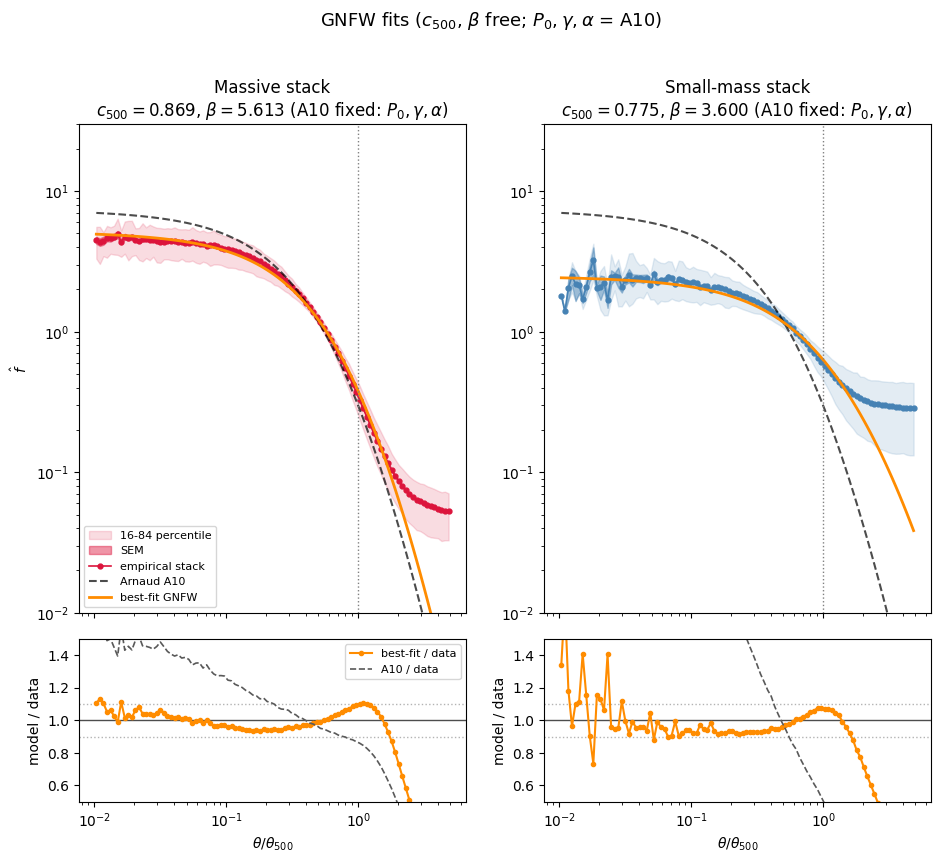

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(11.0, 8.8), sharex='col',
                         gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08})

panels = [
    ('Massive stack', m, fit_massive, 'crimson'),
    ('Small-mass stack', s, fit_small, 'steelblue'),
]

for col, (title, stack, fit, color) in enumerate(panels):
    ax = axes[0, col]
    ax.fill_between(x_mid, stack['p16'], stack['p84'], color=color, alpha=0.15,
                    label='16-84 percentile')
    ax.fill_between(x_mid, stack['fhat'] - stack['sem'], stack['fhat'] + stack['sem'],
                    color=color, alpha=0.45, label='SEM')
    ax.plot(x_mid, stack['fhat'], 'o-', ms=3.5, lw=1.2, color=color, label='empirical stack')
    ax.plot(x_mid, arnaud, 'k--', lw=1.5, alpha=0.7, label='Arnaud A10')
    ax.plot(x_mid, fit['yhat'], '-', color='darkorange', lw=2.0, label='best-fit GNFW')

    p = fit['params']
    ax.set_title(
        f"{title}\n"
        rf"$c_{{500}}={p['c500']:.3f}$, $\beta={p['beta']:.3f}$ "
        rf"(A10 fixed: $P_0,\gamma,\alpha$)"
    )
    ax.set_yscale('log')
    ax.set_ylim(1e-2, 3e1)
    ax.axvline(1.0, color='grey', ls=':', lw=1)
    if col == 0:
        ax.set_ylabel(r'$\hat f$')
        ax.legend(fontsize=8, loc='lower left')

    rax = axes[1, col]
    ratio = fit['yhat'] / stack['fhat']
    rax.axhline(1.0, color='0.3', lw=1)
    rax.axhline(1.1, color='0.7', ls=':', lw=1)
    rax.axhline(0.9, color='0.7', ls=':', lw=1)
    rax.plot(x_mid, ratio, 'o-', ms=3, color='darkorange', label='best-fit / data')
    rax.plot(x_mid, arnaud / stack['fhat'], '--', color='0.35', lw=1.2, label='A10 / data')
    rax.set_ylim(0.5, 1.5)
    rax.set_xlabel(r'$\theta / \theta_{500}$')
    rax.set_ylabel('model / data')
    if col == 0:
        rax.legend(fontsize=8)

for ax in axes[0]:
    ax.set_xscale('log')
for ax in axes[1]:
    ax.set_xscale('log')

fig.suptitle(r'GNFW fits ($c_{500}$, $\beta$ free; $P_0,\gamma,\alpha$ = A10)', y=1.01, fontsize=13)
fig.tight_layout()
plt.show()


## All-cluster stack and GNFW fit

Stack the **100,000 most massive** clusters in the $0<z<3$ window, then fit **$c_{500}$** and **$\beta$** with $P_0$, $\gamma$, and $\alpha$ fixed at A10.


In [24]:
# 100,000 most massive clusters in the redshift window.
N_STACK_ALL = 100_000
all_clusters = window.nlargest(N_STACK_ALL, 'M_500c_Msun')
print(f'stack sample: N={len(all_clusters):,} (most massive in window)  '
      f'M500=[{all_clusters["M_500c_Msun"].min():.2e}, {all_clusters["M_500c_Msun"].max():.2e}]  '
      f'z_med={all_clusters["z"].median():.3f}  theta500_med={all_clusters["theta500_arcmin"].median():.2f} arcmin')

from tqdm.auto import tqdm


def stack_empirical_online(sample, x_edges):
    """Online stack of g = ybar/y_norm; avoids storing N_cluster x N_bin matrix."""
    n_bins = len(x_edges) - 1
    sum_g = np.zeros(n_bins)
    sum_g2 = np.zeros(n_bins)
    count = np.zeros(n_bins, dtype=np.int64)
    n_used = 0
    for _, row in tqdm(sample.iterrows(), total=len(sample), desc='stacking'):
        ybar, y_norm = empirical_profile(
            float(row['theta_rot_rad']), float(row['phi_rot_rad']),
            float(row['theta500_arcmin']), x_edges)
        if not (np.isfinite(y_norm) and y_norm > 0):
            continue
        g = ybar / y_norm
        valid = np.isfinite(g)
        sum_g[valid] += g[valid]
        sum_g2[valid] += g[valid] ** 2
        count[valid] += 1
        n_used += 1
    fhat = np.where(count > 0, sum_g / count, np.nan)
    var = np.where(count > 1, sum_g2 / count - fhat ** 2, np.nan)
    sem = np.where(count > 1, np.sqrt(np.maximum(var, 0.0)) / np.sqrt(count), np.nan)
    return dict(fhat=fhat, sem=sem, n=n_used, count=count)


all_stack = stack_empirical_online(all_clusters, x_edges)
print(f'stacked {all_stack["n"]:,} clusters with valid Y500')
print('bins with >50% clusters contributing:',
      np.sum(all_stack["count"] > 0.5 * all_stack["n"]), '/', len(all_stack["count"]))


stack sample: N=100,000 (most massive in window)  M500=[1.70e+14, 2.07e+15]  z_med=0.625  theta500_med=1.62 arcmin


stacking:   0%|          | 0/100000 [00:00<?, ?it/s]

stacked 100,000 clusters with valid Y500
bins with >50% clusters contributing: 55 / 100


In [25]:
# GNFW fit: c500, beta free; P0, gamma, alpha fixed at A10.
from functools import partial

X_FIT_ALL = (0.01, 2.0)
A10_FIXED_2 = {k: A10_PARAMS[k] for k in ('P0', 'gamma', 'alpha')}

N_QUAD_FIT = 24
_xb_list = [np.linspace(lo, hi, N_QUAD_FIT) for lo, hi in zip(x_edges[:-1], x_edges[1:])]
_xb_cat = np.concatenate(_xb_list)
_bin_slices = np.cumsum([0] + [len(xb) for xb in _xb_list])
_xa_ap = np.linspace(0.0, 1.0, 200)


def _gnfw_params2(c500, beta):
    return dict(c500=float(c500), beta=float(beta), **A10_FIXED_2)


def gnfw_binned_norm_fast2(c500, beta, *, n_s=600):
    pfunc = partial(gnfw, **_gnfw_params2(c500, beta))
    fa = np.asarray(projected_shape(_xa_ap, p_func=pfunc, n_s=n_s))
    ap_mean = 2.0 * np.trapezoid(fa * _xa_ap, _xa_ap)
    fb = np.asarray(projected_shape(_xb_cat, p_func=pfunc, n_s=n_s)) / ap_mean
    out = []
    for i, (lo, hi) in enumerate(zip(x_edges[:-1], x_edges[1:])):
        sl = slice(_bin_slices[i], _bin_slices[i + 1])
        xb = _xb_list[i]
        out.append(2.0 * np.trapezoid(fb[sl] * xb, xb) / (hi**2 - lo**2))
    return np.asarray(out)


def fit_gnfw2_to_stack(stack, x_edges, x_mid, *, x_fit=X_FIT_ALL):
    lo, hi = x_fit
    ok = (
        np.isfinite(stack['fhat']) & (stack['fhat'] > 0)
        & (x_mid >= lo) & (x_mid <= hi)
        & (stack.get('count', stack['n']) > 0.1 * stack['n'])
    )
    y = stack['fhat'][ok]
    logy = np.log(y)

    def search(c5g, btg):
        nonlocal best_chi2, best
        for c5 in c5g:
            for bt in btg:
                m = gnfw_binned_norm_fast2(c5, bt)[ok]
                chi2 = float(np.sum((np.log(m) - logy) ** 2))
                if chi2 < best_chi2:
                    best_chi2, best = chi2, (c5, bt)

    best_chi2 = np.inf
    best = (A10_PARAMS['c500'], A10_PARAMS['beta'])
    search(np.linspace(0.6, 2.0, 17), np.linspace(4.0, 7.0, 17))
    c5b, btb = best
    search(np.linspace(max(0.5, c5b - 0.15), min(3.0, c5b + 0.15), 9),
           np.linspace(max(3.5, btb - 0.4), min(8.0, btb + 0.4), 9))

    params = _gnfw_params2(*best)
    shape = lambda b: projected_shape(b, p_func=partial(gnfw, **params))
    yhat = binned_aperture_normalised_model(x_edges, shape)
    rel = yhat[ok] / y - 1.0
    return dict(
        params=params, yhat=yhat, ok=ok, chi2=best_chi2,
        ndof=int(ok.sum() - 2),
        rms_pct=100 * np.sqrt(np.mean(rel ** 2)),
        max_pct=100 * np.max(np.abs(rel)),
        message=f'2D grid search, chi2={best_chi2:.2f}',
    )


fit_all = fit_gnfw2_to_stack(all_stack, x_edges, x_mid)
p = fit_all['params']
print('100k-cluster GNFW fit')
print(f"  c500={p['c500']:.4f}  beta={p['beta']:.4f}")
print(f"  (fixed: P0={p['P0']:.4f}, gamma={p['gamma']:.4f}, alpha={p['alpha']:.4f})")
print(f"  chi2={fit_all['chi2']:.2f}  ndof={fit_all['ndof']}  "
      f"rms={fit_all['rms_pct']:.2f}%  max|residual|={fit_all['max_pct']:.2f}%")
print('Arnaud A10 reference:', A10_PARAMS)


100k-cluster GNFW fit
  c500=1.2750  beta=3.8000
  (fixed: P0=8.4030, gamma=0.3081, alpha=1.0510)
  chi2=0.21  ndof=56  rms=5.81%  max|residual|=18.92%
Arnaud A10 reference: {'P0': 8.403, 'c500': 1.177, 'gamma': 0.3081, 'alpha': 1.051, 'beta': 5.4905}


/tmp/ipykernel_357360/1238555530.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


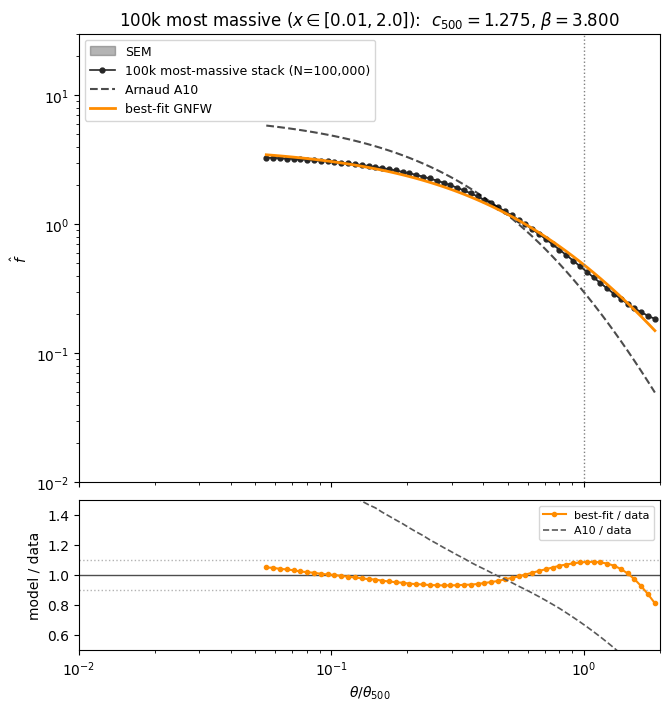

In [26]:
# Plot and fit over the same range: X_FIT_ALL = (0.01, 2.0).
X_PLOT = X_FIT_ALL

plot_ok = (
    np.isfinite(all_stack['fhat']) & (all_stack['fhat'] > 0)
    & np.isfinite(all_stack['sem'])
    & (all_stack['count'] > 0.1 * all_stack['n'])
    & (x_mid >= X_PLOT[0]) & (x_mid <= X_PLOT[1])
)

xp = x_mid[plot_ok]
fp = all_stack['fhat'][plot_ok]
fe = all_stack['sem'][plot_ok]

fig, axes = plt.subplots(2, 1, figsize=(7.5, 8.0), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.06})

ax = axes[0]
ax.fill_between(xp, fp - fe, fp + fe, color='0.35', alpha=0.45, label='SEM')
ax.plot(xp, fp, 'o-', ms=3.5, lw=1.2, color='0.15',
        label=f'100k most-massive stack (N={all_stack["n"]:,})')
ax.plot(xp, arnaud[plot_ok], 'k--', lw=1.5, alpha=0.7, label='Arnaud A10')
ax.plot(xp, fit_all['yhat'][plot_ok], '-', color='darkorange', lw=2.0, label='best-fit GNFW')
p = fit_all['params']
ax.set_title(
    rf"100k most massive ($x\in[{X_PLOT[0]}, {X_PLOT[1]}]$):  "
    rf"$c_{{500}}={p['c500']:.3f}$, $\beta={p['beta']:.3f}$"
)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(X_PLOT[0], X_PLOT[1])
ax.set_ylabel(r'$\hat f$')
ax.set_ylim(1e-2, 3e1)
ax.axvline(1.0, color='grey', ls=':', lw=1)
ax.legend(fontsize=9)

rax = axes[1]
rax.axhline(1.0, color='0.3', lw=1)
rax.axhline(1.1, color='0.7', ls=':', lw=1)
rax.axhline(0.9, color='0.7', ls=':', lw=1)
rax.plot(xp, fit_all['yhat'][plot_ok] / fp, 'o-', ms=3, color='darkorange', label='best-fit / data')
rax.plot(xp, arnaud[plot_ok] / fp, '--', color='0.35', lw=1.2, label='A10 / data')
rax.set_xscale('log')
rax.set_xlim(X_PLOT[0], X_PLOT[1])
rax.set_xlabel(r'$\theta / \theta_{500}$')
rax.set_ylabel('model / data')
rax.set_ylim(0.5, 1.5)
rax.legend(fontsize=8)
fig.tight_layout()
plt.show()
